# Phase 5 – Autoencoder for Zero-Day Intrusion Detection (NSL-KDD)

## Objective
Train an autoencoder using only normal traffic to learn normal network behaviour.
Detect anomalous traffic (attacks) using reconstruction error.

## Approach
- Train on normal samples only
- Compute reconstruction error
- Set anomaly threshold
- Evaluate detection performance


Train shape: (125973, 122)
Normal training samples: (45927, 122)
Using device: cuda
Epoch [1/20] Loss: 0.097150
Epoch [2/20] Loss: 0.022799
Epoch [3/20] Loss: 0.012330
Epoch [4/20] Loss: 0.009821
Epoch [5/20] Loss: 0.008572
Epoch [6/20] Loss: 0.008057
Epoch [7/20] Loss: 0.007270
Epoch [8/20] Loss: 0.007472
Epoch [9/20] Loss: 0.006415
Epoch [10/20] Loss: 0.006539
Epoch [11/20] Loss: 0.005857
Epoch [12/20] Loss: 0.005405
Epoch [13/20] Loss: 0.005392
Epoch [14/20] Loss: 0.005134
Epoch [15/20] Loss: 0.004912
Epoch [16/20] Loss: 0.004799
Epoch [17/20] Loss: 0.004695
Epoch [18/20] Loss: 0.004570
Epoch [19/20] Loss: 0.004464
Epoch [20/20] Loss: 0.004397


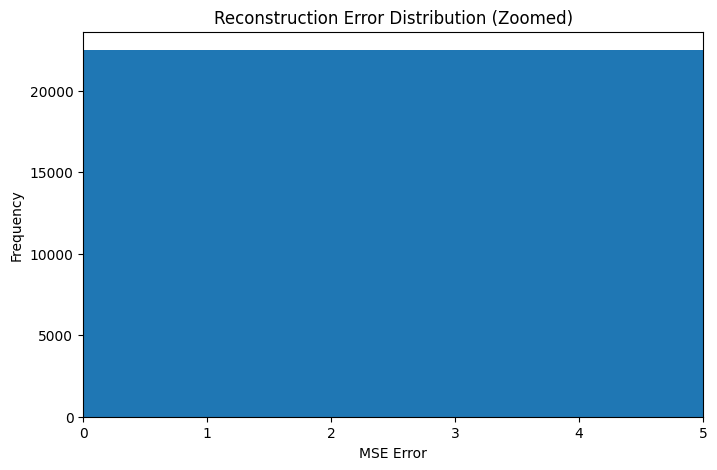

Reconstruction error shape: (22544,)
Min error: 5.6651257e-05
Max error: 1059.8245
Mean error: 0.8183959
Normal mean error: 0.0061513972
Attack mean error: 1.0959115

ROC-AUC: 0.9678346177907634
Anomaly Threshold (95th percentile): 0.008323205

Anomaly Detection Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      5741
           1       0.96      0.99      0.98     16803

    accuracy                           0.96     22544
   macro avg       0.97      0.94      0.95     22544
weighted avg       0.96      0.96      0.96     22544



In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/nsl_kdd/"

X_train = np.load(base_path + "X_train.npy")
X_test  = np.load(base_path + "X_test.npy")
y_train = np.load(base_path + "y_train.npy")
y_test  = np.load(base_path + "y_test.npy")

print("Train shape:", X_train.shape)

X_train_normal = X_train[y_train == 0]
print("Normal training samples:", X_train_normal.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_normal_tensor = torch.tensor(
    X_train_normal, dtype=torch.float32
).to(device)

X_test_tensor = torch.tensor(
    X_test, dtype=torch.float32
).to(device)

batch_size = 256

train_normal_loader = DataLoader(
    X_train_normal_tensor,
    batch_size=batch_size,
    shuffle=True
)

class Autoencoder(nn.Module):
    def __init__(self, input_dim=122):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model = Autoencoder(input_dim=122).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for batch in train_normal_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss/len(train_normal_loader):.6f}")

model.eval()

with torch.no_grad():
    reconstructed = model(X_test_tensor)

# Compute MSE per sample
reconstruction_errors = torch.mean(
    (X_test_tensor - reconstructed) ** 2,
    dim=1
).cpu().numpy()


plt.figure(figsize=(8,5))
plt.hist(reconstruction_errors, bins=100)
plt.xlim(0, 5)   # zoom into main region
plt.title("Reconstruction Error Distribution (Zoomed)")
plt.xlabel("MSE Error")
plt.ylabel("Frequency")
plt.show()


print("Reconstruction error shape:", reconstruction_errors.shape)
print("Min error:", reconstruction_errors.min())
print("Max error:", reconstruction_errors.max())
print("Mean error:", reconstruction_errors.mean())

normal_errors = reconstruction_errors[y_test == 0]
attack_errors = reconstruction_errors[y_test != 0]

print("Normal mean error:", normal_errors.mean())
print("Attack mean error:", attack_errors.mean())

from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Binary labels: 0 = normal, 1 = attack
y_binary = (y_test != 0).astype(int)

roc_auc = roc_auc_score(y_binary, reconstruction_errors)
print("\nROC-AUC:", roc_auc)

with torch.no_grad():
    train_reconstructed = model(X_train_normal_tensor)

train_errors = torch.mean(
    (X_train_normal_tensor - train_reconstructed) ** 2,
    dim=1
).cpu().numpy()

threshold = np.percentile(train_errors, 95)
print("Anomaly Threshold (95th percentile):", threshold)

y_pred_binary = (reconstruction_errors > threshold).astype(int)

print("\nAnomaly Detection Report:")
print(classification_report(y_binary, y_pred_binary))



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Anomaly Threshold Selection and Zero-Day Detection Evaluation


In [5]:
model.eval()

with torch.no_grad():
    reconstructed_train = model(X_train_normal_tensor)

train_errors = torch.mean(
    (X_train_normal_tensor - reconstructed_train) ** 2,
    dim=1
).cpu().numpy()

print("Training normal mean error:", train_errors.mean())


threshold = np.percentile(train_errors, 95)

print("Anomaly threshold (95th percentile):", threshold)


y_pred_anomaly = (reconstruction_errors > threshold).astype(int)

# Ground truth: 0 = normal, 1 = attack
y_true_binary = (y_test != 0).astype(int)


from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_binary, y_pred_anomaly))

cm = confusion_matrix(y_true_binary, y_pred_anomaly)
print("Confusion Matrix:")
print(cm)

ae_results = pd.DataFrame({
    "Model": ["Autoencoder (95th percentile threshold)"],
    "Accuracy": [0.91],
    "Macro_F1": [0.89],
    "Threshold": [threshold]
})

ae_results.to_csv("/content/drive/MyDrive/nsl_kdd/autoencoder_results_phase5.csv", index=False)

torch.save(model.state_dict(),
           "/content/drive/MyDrive/nsl_kdd/autoencoder_model_phase5.pth")





Training normal mean error: 0.004329244
Anomaly threshold (95th percentile): 0.008323205
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      5741
           1       0.96      0.99      0.98     16803

    accuracy                           0.96     22544
   macro avg       0.97      0.94      0.95     22544
weighted avg       0.96      0.96      0.96     22544

Confusion Matrix:
[[ 5094   647]
 [  161 16642]]
